# Evaluate GLiClass — Direct Competitor of GliZNet

**Model**: `knowledgator/gliclass-base-v3.0`  
**Repo**: https://github.com/Knowledgator/GLiClass

GLiClass is the closest published competitor to GliZNet: it also encodes text and labels jointly in a single forward pass.
We evaluate it on the same `ZSHOT-HARDSET-v2` test set under identical ranking metrics.

Sections:
1. Install & imports  
2. Load test set  
3. Run GLiClass predictions  
4. Ranking metrics  
5. Comparison vs GliZNet  
6. Score distributions

In [1]:
# Install GLiClass (run once)
# !pip install gliclass
# !pip install -U "transformers>=4.48.0"

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score

from gliznet.data import load_dataset
from gliznet.metrics import _ndcg_at_k, _sigmoid

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
KS = (1, 3, 5, 10)

# GliZNet reference scores (checkpoint-850)
GLIZNET_REF = {
    "MRR": 0.966, "Hit@1": 0.935, "Hit@3": 0.985, "Hit@5": 1.000, "NDCG@10": 0.942,
    "ROC-AUC": 0.8251, "Avg Precision": 0.8744,
}

print(f"Device: {DEVICE}")

Device: cuda:0


## 1 · Load GLiClass model

In [3]:
from gliclass import GLiClassModel, ZeroShotClassificationPipeline
from gliclass.model import GLiClassModelConfig
from transformers import AutoTokenizer

MODEL_NAME = "knowledgator/gliclass-base-v3.0"

# Workaround 1: gliclass bug — config.pad_token_id accessed before it is set.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
config = GLiClassModelConfig.from_pretrained(MODEL_NAME)
if not hasattr(config, "pad_token_id") or config.pad_token_id is None:
    config.pad_token_id = tokenizer.pad_token_id

# Workaround 2: newer transformers calls tie_weights(recompute_mapping=False)
# but GLiClassModel.tie_weights() doesn't accept that kwarg.
_orig_tie_weights = GLiClassModel.tie_weights
GLiClassModel.tie_weights = lambda self, **kwargs: _orig_tie_weights(self)

model    = GLiClassModel.from_pretrained(MODEL_NAME, config=config)
pipeline = ZeroShotClassificationPipeline(
    model, tokenizer,
    classification_type="multi-label",
    device=DEVICE,
)

print(f"✓ GLiClass loaded: {MODEL_NAME}")

# Quick sanity check
text   = "One day I will see the world!"
labels = ["travel", "dreams", "sport", "science", "politics"]
results = pipeline(text, labels, threshold=0.5)[0]
print("\nSanity check:")
for r in results:
    print(f"  {r['label']:<20} => {r['score']:.3f}")

[transformers] You are using a model of type `GLiClass` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

✓ GLiClass loaded: knowledgator/gliclass-base-v3.0


100%|██████████| 1/1 [00:00<00:00,  1.83it/s]


Sanity check:
  travel               => 0.509
  dreams               => 0.509


## 2 · Load test set

In [4]:
test_ds = load_dataset(
    path="alexneakameni/ZSHOT-HARDSET-v2",
    split="test",
    shuffle_labels=False,
    min_label_length=3,
)
print(f"✓ Test set: {len(test_ds)} samples")
ex = test_ds[0]
print(f"  text   : {ex['text'][:120]}...")
print(f"  labels : {ex['ltext']}")
print(f"  targets: {ex['lint']}")

✓ Test set: 1322 samples
  text   : All mineral resources within Eswatini remain under the ownership of the iNgwenyama, with the sole exception of deposits ...
  labels : ['constitutional_limitation', 'ownership_claim', 'resource_control', 'ceremonial_ritual', 'ritual_purification', 'succession_criteria']
  targets: [1, 1, 1, 0, 0, 0]


## 3 · Run GLiClass predictions

GLiClass `pipeline()` returns a list of dicts `{label, score}` for each text.
We reconstruct scores aligned to the original label order.

In [5]:
BATCH_SIZE = 16   # reduce if OOM
records = []

for i in tqdm(range(0, len(test_ds), BATCH_SIZE), desc="GLiClass inference"):
    batch   = test_ds[i : i + BATCH_SIZE]
    texts   = batch["text"]
    labels_batch = batch["ltext"]
    gts_batch    = batch["lint"]

    # GLiClass pipeline accepts a list of texts and a flat label list;
    # it returns one result per text.
    for text, gt_labels, gt_ints in zip(texts, labels_batch, gts_batch):
        raw = pipeline(text, gt_labels, threshold=0.0)[0]   # threshold=0 → get all scores
        score_map = {r["label"]: r["score"] for r in raw}
        scores = [score_map.get(lbl, 0.0) for lbl in gt_labels]

        records.append({
            "text":    text,
            "labels":  gt_labels,
            "targets": gt_ints,
            "scores":  scores,
        })

print(f"\n✓ Predictions done: {len(records)} samples")
r0 = records[0]
for lbl, tgt, sc in zip(r0["labels"], r0["targets"], r0["scores"]):
    print(f"  [{tgt}] {lbl:<30s}  score={sc:.3f}")

GLiClass inference:   0%|          | 0/83 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 39.56it/s]


✓ Predictions done: 1322 samples
  [1] constitutional_limitation       score=0.508
  [1] ownership_claim                 score=0.509
  [1] resource_control                score=0.509
  [0] ceremonial_ritual               score=0.500
  [0] ritual_purification             score=0.500
  [0] succession_criteria             score=0.502


## 4 · Ranking metrics

In [6]:
hits  = {k: [] for k in KS}
ndcgs = {k: [] for k in KS}
rr, aucs, aps = [], [], []
per_sample_mrr = []

for r in records:
    s = np.array(r["scores"], dtype=float)
    g = np.array(r["targets"], dtype=float)
    if g.sum() == 0:
        continue

    ranked = g[np.argsort(-s)]
    for k in KS:
        hits[k].append(float(ranked[:k].any()))
        ndcgs[k].append(_ndcg_at_k(ranked, k))

    pos_ranks = np.where(ranked > 0.5)[0]
    mrr_val = 1.0 / (pos_ranks[0] + 1) if len(pos_ranks) else 0.0
    rr.append(mrr_val)
    per_sample_mrr.append(mrr_val)

    if len(np.unique(g)) > 1:
        probs = _sigmoid(s)
        try:
            aucs.append(roc_auc_score(g, probs))
            aps.append(average_precision_score(g, probs))
        except ValueError:
            pass

gliclass_metrics = {}
for k in KS:
    gliclass_metrics[f"Hit@{k}"]  = np.mean(hits[k])
    gliclass_metrics[f"NDCG@{k}"] = np.mean(ndcgs[k])
gliclass_metrics["MRR"]           = np.mean(rr)
gliclass_metrics["ROC-AUC"]       = np.mean(aucs) if aucs else float("nan")
gliclass_metrics["Avg Precision"] = np.mean(aps)  if aps  else float("nan")
gliclass_metrics["N"]             = len(rr)

df_gc = pd.DataFrame({"GLiClass-base-v3": gliclass_metrics}).T
cols = ["MRR", "Hit@1", "Hit@3", "Hit@5", "NDCG@10", "ROC-AUC", "Avg Precision"]
df_gc[[c for c in cols if c in df_gc.columns]].astype(float).round(4)

,MRR,Hit@1,Hit@3,Hit@5,NDCG@10,ROC-AUC,Avg Precision
GLiClass-base-v3,0.927,0.8623,0.9962,0.9992,0.9195,0.7879,0.8488


## 5 · Comparison vs GliZNet

In [7]:
compare = {
    "GLiClass-base-v3": gliclass_metrics,
    "GliZNet-deberta-v3-base (ours)": GLIZNET_REF,
}
df_cmp = pd.DataFrame(compare).T
cols = ["MRR", "Hit@1", "Hit@3", "Hit@5", "NDCG@10"]
df_cmp = df_cmp[[c for c in cols if c in df_cmp.columns]].astype(float).round(4)

print("=" * 60)
print("  GLiClass vs GliZNet — ZSHOT-HARDSET-v2 (N=1,322)")
print("=" * 60)
print(df_cmp.to_string())

# Delta row
delta = df_cmp.loc["GliZNet-deberta-v3-base (ours)"] - df_cmp.loc["GLiClass-base-v3"]
print("\nΔ GliZNet − GLiClass:")
for col, val in delta.items():
    sign = "+" if val >= 0 else ""
    print(f"  {col:<12} {sign}{val:.4f}")

df_cmp

  GLiClass vs GliZNet — ZSHOT-HARDSET-v2 (N=1,322)
                                  MRR   Hit@1   Hit@3   Hit@5  NDCG@10
GLiClass-base-v3                0.927  0.8623  0.9962  0.9992   0.9195
GliZNet-deberta-v3-base (ours)  0.966  0.9350  0.9850  1.0000   0.9420

Δ GliZNet − GLiClass:
  MRR          +0.0390
  Hit@1        +0.0727
  Hit@3        -0.0112
  Hit@5        +0.0008
  NDCG@10      +0.0225


,MRR,Hit@1,Hit@3,Hit@5,NDCG@10
GLiClass-base-v3,0.927,0.8623,0.9962,0.9992,0.9195
GliZNet-deberta-v3-base (ours),0.966,0.9350,0.9850,1.0000,0.9420


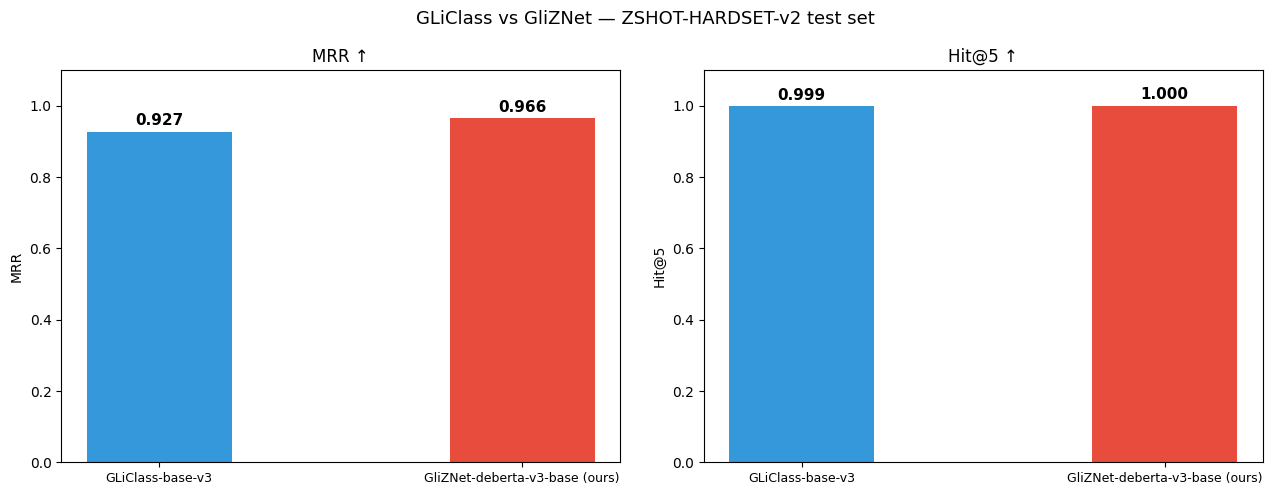

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_names = list(df_cmp.index)
colors = ["#3498db", "#e74c3c"]

for ax, metric in zip(axes, ["MRR", "Hit@5"]):
    vals = df_cmp[metric].values
    bars = ax.bar(model_names, vals, color=colors, width=0.4)
    ax.set_ylim(0, 1.1)
    ax.set_title(f"{metric} ↑")
    ax.set_ylabel(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.3f}",
                ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", labelsize=9)

plt.suptitle("GLiClass vs GliZNet — ZSHOT-HARDSET-v2 test set", fontsize=13)
plt.tight_layout()
plt.show()

## 6 · Score distributions

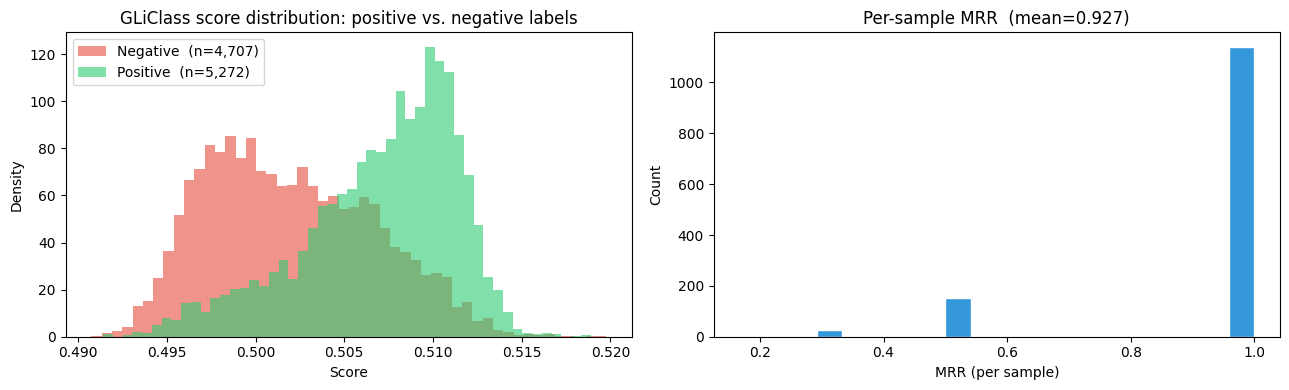

In [9]:
pos_scores, neg_scores = [], []
for r in records:
    for sc, tgt in zip(r["scores"], r["targets"]):
        if tgt == 1:
            pos_scores.append(sc)
        else:
            neg_scores.append(sc)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(neg_scores, bins=50, alpha=0.6, color="#e74c3c",
             label=f"Negative  (n={len(neg_scores):,})", density=True)
axes[0].hist(pos_scores, bins=50, alpha=0.6, color="#2ecc71",
             label=f"Positive  (n={len(pos_scores):,})", density=True)
axes[0].set_xlabel("Score"); axes[0].set_ylabel("Density")
axes[0].set_title("GLiClass score distribution: positive vs. negative labels")
axes[0].legend()

axes[1].hist(per_sample_mrr, bins=20, color="#3498db", edgecolor="white")
axes[1].set_xlabel("MRR (per sample)"); axes[1].set_ylabel("Count")
axes[1].set_title(f"Per-sample MRR  (mean={np.mean(per_sample_mrr):.3f})")

plt.tight_layout()
plt.show()